# E5 — Forms of life / grounding (capstone)

*A working demonstration of Beetle-Box experiment **E5**. Full write-up:
[`docs/e5_forms_of_life.md`](../docs/e5_forms_of_life.md). Runs on CPU in ~a minute.*

**The crux.** Does meaning live in the public moves alone, or in how those moves
are woven into a **form of life**? For Wittgenstein "use" is not bare word-statistics
but use embedded in the surrounding activity of a creature. This is the fault line
the LLM question keeps hitting.

E5 gives it an operational handle. We run E1's signaling game two ways —
**ungrounded** (symbols are pure labels; reward = identify the referent) and
**grounded** (the receiver *acts*, and reward is the world payoff of the action,
with per-referent stakes) — and ask whether grounding changes the **character** of
the emergent language. Same referents, same channel; only the consequences differ.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt

from beetlebox.config import E5RunConfig, E5ExperimentConfig
from beetlebox.harness import E5RunManager
from beetlebox.envs import SignalingEnv
from beetlebox.analysis import e5

warnings.filterwarnings("ignore")
OKABE = {"blue": "#0072B2", "orange": "#E69F00", "green": "#009E73", "vermil": "#D55E00"}
plt.rcParams.update({"figure.figsize": (7.2, 4.3), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.25, "axes.titleweight": "bold", "font.size": 10})

def run(grounded, steps=4000, seed=0):
    cfg = E5RunConfig(seed=seed)
    cfg.experiment = E5ExperimentConfig(grounded=grounded, num_steps=steps, eval_every=500,
                                        robustness_noise=0.25, turnover=True, turnover_at=0.6)
    cfg.env.mode = "grid"; cfg.env.num_attributes = 2; cfg.env.num_values = 4
    cfg.channel.vocab_size = 6; cfg.channel.message_length = 2
    s = E5RunManager(cfg).run()
    env = SignalingEnv(cfg.env)
    recover, lexicon = e5.recoverability(s["final_mapping"], env)
    s["recover"] = recover; s["lexicon"] = lexicon
    return s

runs = {"ungrounded": run(False), "grounded": run(True)}
for name, s in runs.items():
    print(f"{name:10s} performance={s['performance']:.3f}  lexicon={s['lexicon']}/16  "
          f"relevant_recover={s['recover'][0]:.3f}  irrelevant_recover={s['recover'][1]:.3f}")

ungrounded performance=0.938  lexicon=15/16  relevant_recover=0.875  irrelevant_recover=0.875
grounded   performance=1.000  lexicon=4/16  relevant_recover=1.000  irrelevant_recover=0.000


## 1. Grounding makes the language selective

The clearest signature is **what the language bothers to encode**. For each grid
attribute we measure *recoverability*: can you read the attribute's value off the
message? The correct action depends only on **attribute 0** (the payoff-relevant
one); **attribute 1** is payoff-neutral but sets the stakes.

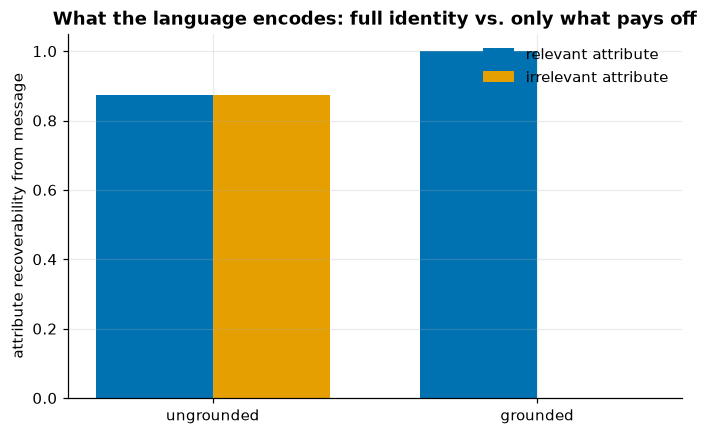

In [2]:
labels = ["ungrounded", "grounded"]
rel = [runs[k]["recover"][0] for k in labels]
irr = [runs[k]["recover"][1] for k in labels]
x = np.arange(len(labels)); w = 0.36
fig, ax = plt.subplots()
ax.bar(x - w/2, rel, w, color=OKABE["blue"], label="relevant attribute")
ax.bar(x + w/2, irr, w, color=OKABE["orange"], label="irrelevant attribute")
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylim(0, 1.05)
ax.set_ylabel("attribute recoverability from message")
ax.set_title("What the language encodes: full identity vs. only what pays off")
ax.legend(frameon=False, loc="upper right"); plt.show()

- **Ungrounded**: both attributes are recoverable — the language encodes **full
  identity** (a near-unique message per referent, lexicon ≈ 16/16).
- **Grounded**: the relevant attribute is fully recoverable, the irrelevant one is
  **completely discarded** — a tiny lexicon (≈ 4/16), one message per payoff value.

Same referents, same channel; the **consequential task reshaped what the language
marks**. That is the form of life being load-bearing.

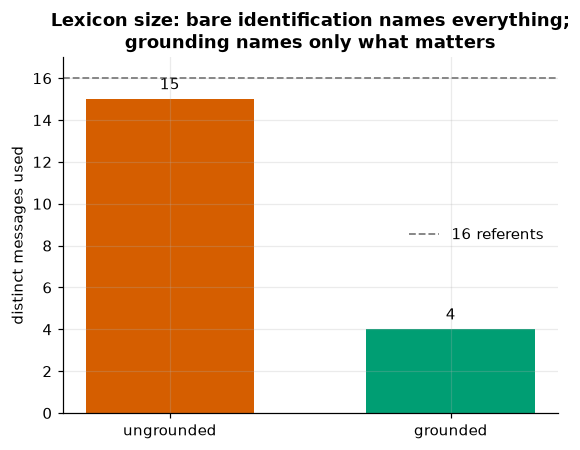

In [3]:
# Lexicon size makes the same point: grounded needs far fewer distinct words.
lex = [runs[k]["lexicon"] for k in labels]
fig, ax = plt.subplots(figsize=(5.8, 4.2))
bars = ax.bar(labels, lex, color=[OKABE["vermil"], OKABE["green"]], width=0.6)
ax.axhline(16, color="0.5", ls="--", lw=1.2, label="16 referents")
ax.set_ylabel("distinct messages used"); ax.set_ylim(0, 17)
ax.set_title("Lexicon size: bare identification names everything;\ngrounding names only what matters")
for b, v in zip(bars, lex):
    ax.text(b.get_x()+b.get_width()/2, v+0.3, str(v), ha="center", va="bottom")
ax.legend(frameon=False, loc="center right"); plt.show()

## 2. Performance, robustness, transfer

Both regimes succeed at their own task (identification vs. payoff), both largely
recover after a fresh receiver is swapped in (**transfer** via turnover), and both
degrade under channel noise (**robustness**). These are reported for completeness;
the *character* change above is the headline.

In [4]:
for name, s in runs.items():
    tr = f"{s['post_turnover_performance']:.2f}/{s['pre_turnover_performance']:.2f}" \
         if s["pre_turnover_performance"] is not None else "n/a"
    print(f"{name:10s} performance={s['performance']:.3f}  "
          f"robustness_ratio={s['robustness_ratio']:.3f}  transfer(post/pre)={tr}")

ungrounded performance=0.938  robustness_ratio=0.733  transfer(post/pre)=0.94/0.94
grounded   performance=1.000  robustness_ratio=0.650  transfer(post/pre)=1.00/1.00


## What E5 does (and does not) license

If grounding measurably changes the character of the emergent language — here,
making it **selective** where bare identification encodes full identity — that is
evidence the **form of life is load-bearing**: the surrounding activity, not the
tokens alone, shapes what the language means. This is the sharpest operational
handle on the LLM fault line (public moves vs. embedding in a form of life). It does
**not** show the agents understand anything, nor prove an ungrounded language could
never be pushed to behave the same under a different pressure. Report the change in
character, not a verdict on understanding. (`plan/beetle-box.md` §4.5)

See the [approach doc](../docs/e5_forms_of_life.md), the
[exemplary run](../results/exemplary/e5_forms_of_life/), and the annotated
[supplemental reading](../docs/supplemental_reading.md).